# Music Genre Classification Using Machine Learning

### Machine Learning Mini-Project

**Problem:** Classify music samples into their respective genres using extracted audio features.

**Best Model:** Random Forest  
**Best Test Accuracy:** 70.77%

In [40]:
import pandas as pd
import numpy as np

# Load the 3-second music features dataset
df = pd.read_csv("../data/features_3_sec.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9990, 60)


In [41]:
# Display all column names
print("Number of columns:", len(df.columns))
print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of columns: 60

Column names:
1. filename
2. length
3. chroma_stft_mean
4. chroma_stft_var
5. rms_mean
6. rms_var
7. spectral_centroid_mean
8. spectral_centroid_var
9. spectral_bandwidth_mean
10. spectral_bandwidth_var
11. rolloff_mean
12. rolloff_var
13. zero_crossing_rate_mean
14. zero_crossing_rate_var
15. harmony_mean
16. harmony_var
17. perceptr_mean
18. perceptr_var
19. tempo
20. mfcc1_mean
21. mfcc1_var
22. mfcc2_mean
23. mfcc2_var
24. mfcc3_mean
25. mfcc3_var
26. mfcc4_mean
27. mfcc4_var
28. mfcc5_mean
29. mfcc5_var
30. mfcc6_mean
31. mfcc6_var
32. mfcc7_mean
33. mfcc7_var
34. mfcc8_mean
35. mfcc8_var
36. mfcc9_mean
37. mfcc9_var
38. mfcc10_mean
39. mfcc10_var
40. mfcc11_mean
41. mfcc11_var
42. mfcc12_mean
43. mfcc12_var
44. mfcc13_mean
45. mfcc13_var
46. mfcc14_mean
47. mfcc14_var
48. mfcc15_mean
49. mfcc15_var
50. mfcc16_mean
51. mfcc16_var
52. mfcc17_mean
53. mfcc17_var
54. mfcc18_mean
55. mfcc18_var
56. mfcc19_mean
57. mfcc19_var
58. mfcc20_mean
59. mfcc20_var
60. la

In [42]:
# Display the first 5 rows
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [43]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harmony_mean            

In [44]:
# Check the number of songs/examples in each genre
print("Number of unique genres:", df["label"].nunique())

print("\nGenre distribution:")
print(df["label"].value_counts())

Number of unique genres: 10

Genre distribution:
label
blues        1000
jazz         1000
pop          1000
reggae       1000
metal        1000
disco         999
classical     998
hiphop        998
rock          998
country       997
Name: count, dtype: int64


In [45]:
# Check whether the dataset is balanced
genre_counts = df["label"].value_counts()

print("Minimum samples in a genre:", genre_counts.min())
print("Maximum samples in a genre:", genre_counts.max())
print("Difference:", genre_counts.max() - genre_counts.min())

Minimum samples in a genre: 997
Maximum samples in a genre: 1000
Difference: 3


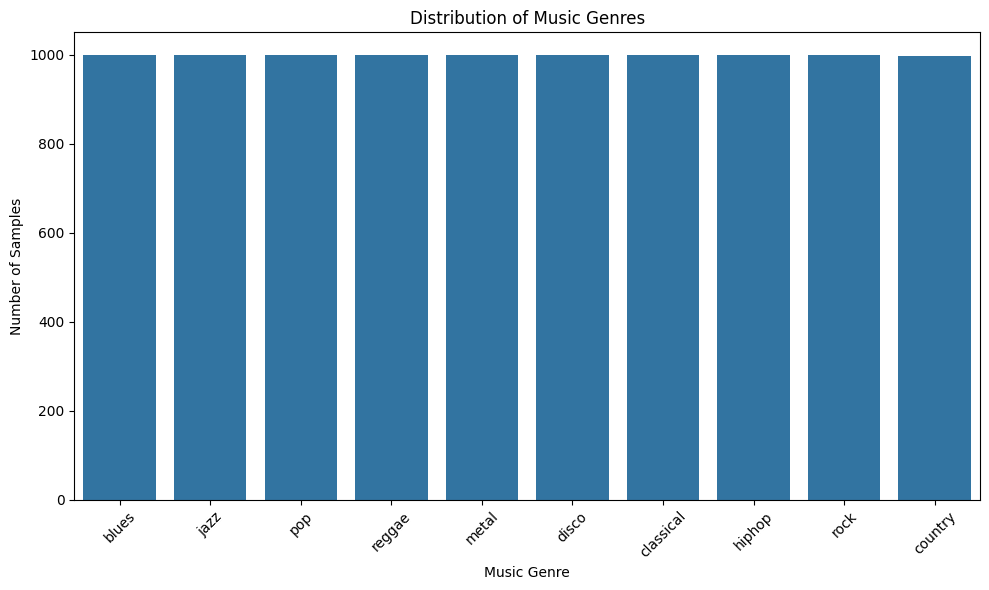

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count samples in each genre
genre_counts = df["label"].value_counts()

# Plot genre distribution
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values
)

plt.title("Distribution of Music Genres")
plt.xlabel("Music Genre")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

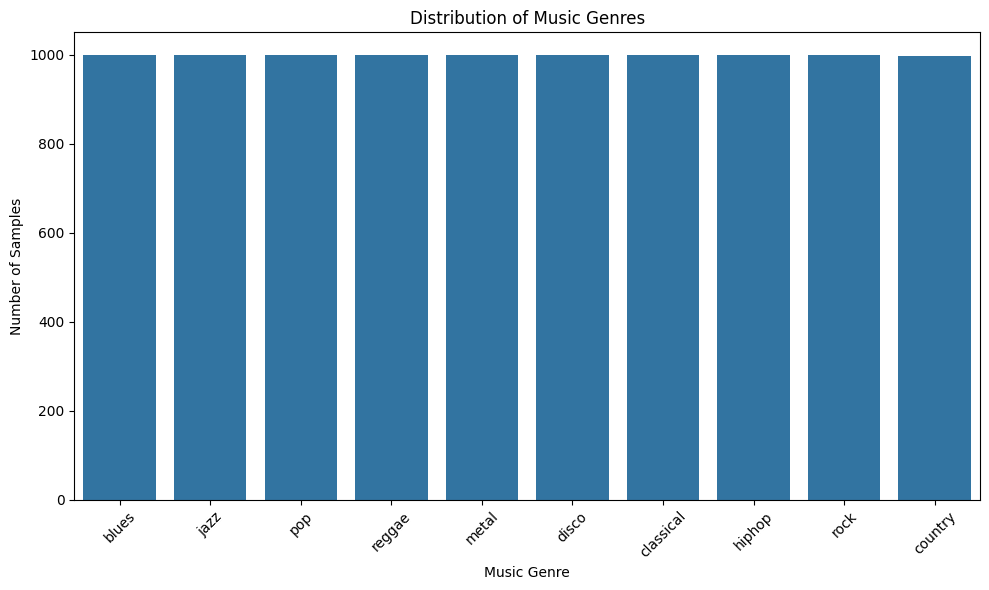

In [47]:
# Save the genre distribution graph
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values
)

plt.title("Distribution of Music Genres")
plt.xlabel("Music Genre")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../results/genre_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

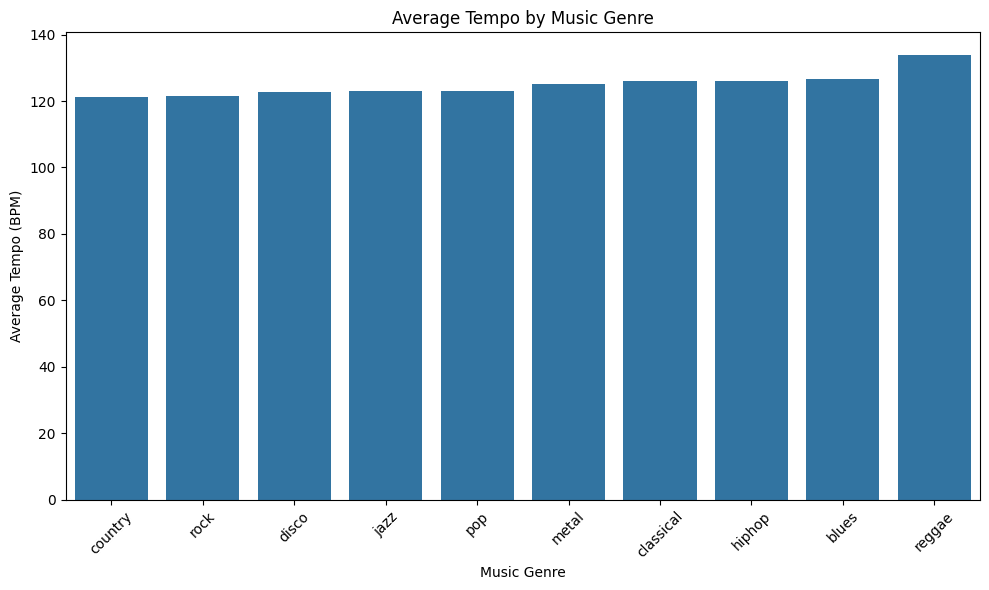

In [48]:
# Compare average tempo across music genres

tempo_by_genre = df.groupby("label")["tempo"].mean().sort_values()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=tempo_by_genre.index,
    y=tempo_by_genre.values
)

plt.title("Average Tempo by Music Genre")
plt.xlabel("Music Genre")
plt.ylabel("Average Tempo (BPM)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
# Statistical summary of numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
length,9990.0,6.614900e+04,0.000000e+00,6.614900e+04,66149.000000,6.614900e+04,6.614900e+04,6.614900e+04
chroma_stft_mean,9990.0,3.795341e-01,9.046576e-02,1.071078e-01,0.315698,3.847409e-01,4.424433e-01,7.494808e-01
chroma_stft_var,9990.0,8.487615e-02,9.636622e-03,1.534475e-02,0.079833,8.510794e-02,9.109229e-02,1.209643e-01
rms_mean,9990.0,1.308591e-01,6.854539e-02,9.534877e-04,0.083782,1.212534e-01,1.763277e-01,4.425668e-01
rms_var,9990.0,2.676388e-03,3.585628e-03,4.379535e-08,0.000615,1.491318e-03,3.130862e-03,3.261522e-02
spectral_centroid_mean,9990.0,2.199219e+03,7.518606e+02,4.727416e+02,1630.680158,2.208628e+03,2.712582e+03,5.432534e+03
spectral_centroid_var,9990.0,4.166727e+05,4.349644e+05,8.118813e+02,123196.130771,2.650692e+05,5.624152e+05,4.794119e+06
spectral_bandwidth_mean,9990.0,2.241386e+03,5.438544e+02,4.991629e+02,1887.455790,2.230576e+03,2.588341e+03,3.708148e+03
spectral_bandwidth_var,9990.0,1.182711e+05,1.013505e+05,1.183520e+03,48765.526957,8.996072e+04,1.585674e+05,1.235143e+06
rolloff_mean,9990.0,4.566077e+03,1.642065e+03,6.583363e+02,3378.311110,4.631378e+03,5.591635e+03,9.487446e+03


In [50]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [51]:
# Check for missing values

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

# Show columns with missing values, if any
print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Total missing values: 0

Columns with missing values:
Series([], dtype: int64)


In [52]:
# Separate input features (X) and target variable (y)

# Remove filename, length, and label from the input features
X = df.drop(columns=["filename", "length", "label"])

# Target variable
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:", X.shape[1])
print("Number of target classes:", y.nunique())

X shape: (9990, 57)
y shape: (9990,)

Number of features: 57
Number of target classes: 10


In [53]:
# Verify that all model input features are numeric

print("Non-numeric columns in X:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

Non-numeric columns in X:
[]


In [54]:
# Extract the original song ID from the filename
# Example: blues.00000.0.wav -> blues.00000

df["song_id"] = df["filename"].str.rsplit(".", n=2).str[0]

print(df[["filename", "song_id", "label"]].head(10))

            filename      song_id  label
0  blues.00000.0.wav  blues.00000  blues
1  blues.00000.1.wav  blues.00000  blues
2  blues.00000.2.wav  blues.00000  blues
3  blues.00000.3.wav  blues.00000  blues
4  blues.00000.4.wav  blues.00000  blues
5  blues.00000.5.wav  blues.00000  blues
6  blues.00000.6.wav  blues.00000  blues
7  blues.00000.7.wav  blues.00000  blues
8  blues.00000.8.wav  blues.00000  blues
9  blues.00000.9.wav  blues.00000  blues


In [55]:
from sklearn.model_selection import StratifiedGroupKFold

# Create groups based on original songs
groups = df["song_id"]

# StratifiedGroupKFold keeps songs together while maintaining genre balance
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Get the first train/test split
train_idx, test_idx = next(
    sgkf.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining songs:", groups.iloc[train_idx].nunique())
print("Testing songs:", groups.iloc[test_idx].nunique())

print("\nTraining genre distribution:")
print(y_train.value_counts())

print("\nTesting genre distribution:")
print(y_test.value_counts())

Training samples: 7992
Testing samples: 1998

Training songs: 800
Testing songs: 200

Training genre distribution:
label
blues        800
jazz         800
pop          800
reggae       800
metal        800
disco        799
hiphop       799
classical    798
country      798
rock         798
Name: count, dtype: int64

Testing genre distribution:
label
blues        200
classical    200
disco        200
jazz         200
pop          200
metal        200
reggae       200
rock         200
hiphop       199
country      199
Name: count, dtype: int64


In [56]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (7992, 57)
Scaled testing data shape: (1998, 57)


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create the model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 68.07 %


In [58]:
print("Classification Report - Logistic Regression\n")

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

       blues       0.60      0.71      0.65       200
   classical       0.93      0.97      0.95       200
     country       0.68      0.53      0.60       199
       disco       0.59      0.53      0.55       200
      hiphop       0.66      0.59      0.62       199
        jazz       0.83      0.78      0.80       200
       metal       0.76      0.81      0.78       200
         pop       0.76      0.78      0.77       200
      reggae       0.60      0.60      0.60       200
        rock       0.44      0.52      0.48       200

    accuracy                           0.68      1998
   macro avg       0.68      0.68      0.68      1998
weighted avg       0.68      0.68      0.68      1998



In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=10
)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:",
      round(knn_accuracy * 100, 2), "%")

KNN Accuracy: 65.72 %


In [60]:
print("Classification Report - KNN\n")

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

Classification Report - KNN

              precision    recall  f1-score   support

       blues       0.73      0.77      0.75       200
   classical       0.86      0.93      0.89       200
     country       0.61      0.59      0.60       199
       disco       0.45      0.58      0.51       200
      hiphop       0.58      0.62      0.60       199
        jazz       0.73      0.69      0.71       200
       metal       0.81      0.76      0.79       200
         pop       0.82      0.70      0.76       200
      reggae       0.56      0.53      0.54       200
        rock       0.47      0.41      0.43       200

    accuracy                           0.66      1998
   macro avg       0.66      0.66      0.66      1998
weighted avg       0.66      0.66      0.66      1998



In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = decision_tree_model.predict(X_test_scaled)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:",
      round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 50.85 %


In [62]:
print("Classification Report - Decision Tree\n")

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Classification Report - Decision Tree

              precision    recall  f1-score   support

       blues       0.55      0.61      0.58       200
   classical       0.86      0.89      0.87       200
     country       0.38      0.33      0.35       199
       disco       0.34      0.38      0.36       200
      hiphop       0.42      0.44      0.43       199
        jazz       0.63      0.56      0.59       200
       metal       0.56      0.57      0.57       200
         pop       0.69      0.67      0.68       200
      reggae       0.38      0.39      0.38       200
        rock       0.27      0.26      0.26       200

    accuracy                           0.51      1998
   macro avg       0.51      0.51      0.51      1998
weighted avg       0.51      0.51      0.51      1998



In [63]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create the SVM model
svm_model = SVC(
    kernel="linear",
    random_state=42
)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:",
      round(svm_accuracy * 100, 2), "%")

SVM Accuracy: 67.37 %


In [64]:
print("Classification Report - SVM\n")

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

Classification Report - SVM

              precision    recall  f1-score   support

       blues       0.57      0.81      0.67       200
   classical       0.94      0.98      0.96       200
     country       0.62      0.50      0.56       199
       disco       0.56      0.53      0.54       200
      hiphop       0.62      0.58      0.60       199
        jazz       0.84      0.71      0.77       200
       metal       0.84      0.81      0.82       200
         pop       0.77      0.75      0.76       200
      reggae       0.60      0.55      0.57       200
        rock       0.45      0.50      0.47       200

    accuracy                           0.67      1998
   macro avg       0.68      0.67      0.67      1998
weighted avg       0.68      0.67      0.67      1998



In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test_scaled)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 70.77 %


In [66]:
print("Classification Report - Random Forest\n")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Classification Report - Random Forest

              precision    recall  f1-score   support

       blues       0.68      0.81      0.74       200
   classical       0.96      1.00      0.98       200
     country       0.62      0.65      0.63       199
       disco       0.57      0.53      0.55       200
      hiphop       0.72      0.64      0.68       199
        jazz       0.80      0.83      0.82       200
       metal       0.76      0.84      0.80       200
         pop       0.79      0.84      0.81       200
      reggae       0.60      0.57      0.59       200
        rock       0.50      0.36      0.42       200

    accuracy                           0.71      1998
   macro avg       0.70      0.71      0.70      1998
weighted avg       0.70      0.71      0.70      1998



In [67]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Create the Perceptron model
perceptron_model = Perceptron(
    max_iter=1000,
    random_state=42
)

# Train the model
perceptron_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_perceptron = perceptron_model.predict(X_test_scaled)

# Calculate accuracy
perceptron_accuracy = accuracy_score(y_test, y_pred_perceptron)

print("Perceptron Accuracy:",
      round(perceptron_accuracy * 100, 2), "%")

Perceptron Accuracy: 53.4 %


In [68]:
print("Classification Report - Perceptron\n")

print(
    classification_report(
        y_test,
        y_pred_perceptron
    )
)

Classification Report - Perceptron

              precision    recall  f1-score   support

       blues       0.57      0.55      0.56       200
   classical       0.90      0.92      0.91       200
     country       0.55      0.49      0.52       199
       disco       0.25      0.28      0.26       200
      hiphop       0.47      0.53      0.50       199
        jazz       0.67      0.51      0.58       200
       metal       0.58      0.77      0.66       200
         pop       0.73      0.34      0.47       200
      reggae       0.59      0.56      0.58       200
        rock       0.28      0.39      0.33       200

    accuracy                           0.53      1998
   macro avg       0.56      0.53      0.54      1998
weighted avg       0.56      0.53      0.54      1998



In [69]:
# Compare model accuracies

model_names = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "SVM",
    "Random Forest",
    "Perceptron"
]

accuracies = [
    logistic_accuracy,
    knn_accuracy,
    dt_accuracy,
    svm_accuracy,
    rf_accuracy,
    perceptron_accuracy
]

for name, accuracy in zip(model_names, accuracies):
    print(f"{name}: {accuracy * 100:.2f}%")

Logistic Regression: 68.07%
KNN: 65.72%
Decision Tree: 50.85%
SVM: 67.37%
Random Forest: 70.77%
Perceptron: 53.40%


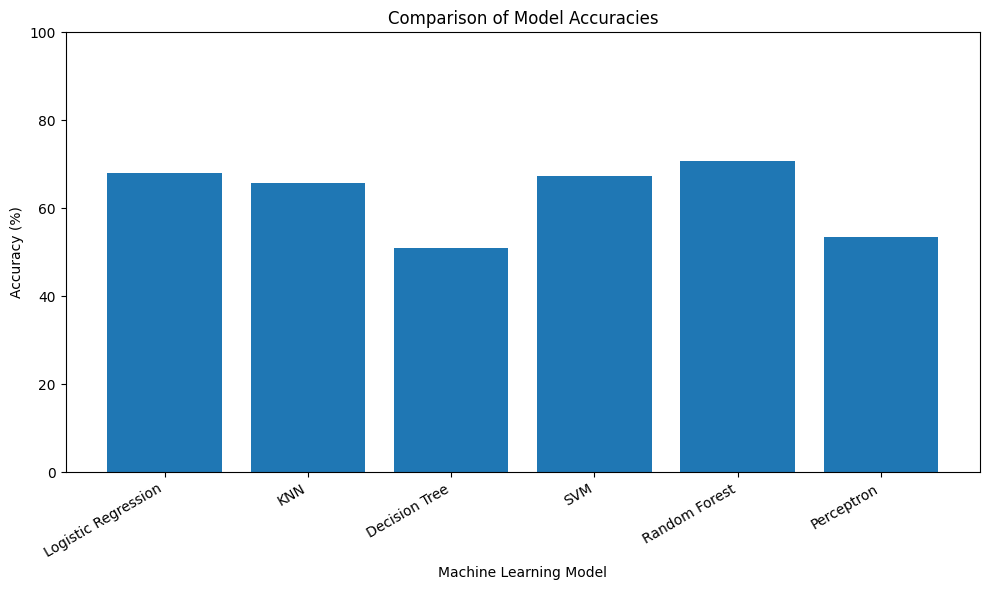

In [70]:
import matplotlib.pyplot as plt

# Convert accuracies to percentages
accuracy_percentages = [accuracy * 100 for accuracy in accuracies]

plt.figure(figsize=(10, 6))

plt.bar(model_names, accuracy_percentages)

plt.title("Comparison of Model Accuracies")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [76]:
# Predict the genre of a test song using the best model

sample_index = 8

predicted_genre = random_forest_model.predict(
    X_test_scaled[sample_index].reshape(1, -1)
)[0]

actual_genre = y_test.iloc[sample_index]

print("Actual Genre:", actual_genre)
print("Predicted Genre:", predicted_genre)

Actual Genre: blues
Predicted Genre: country


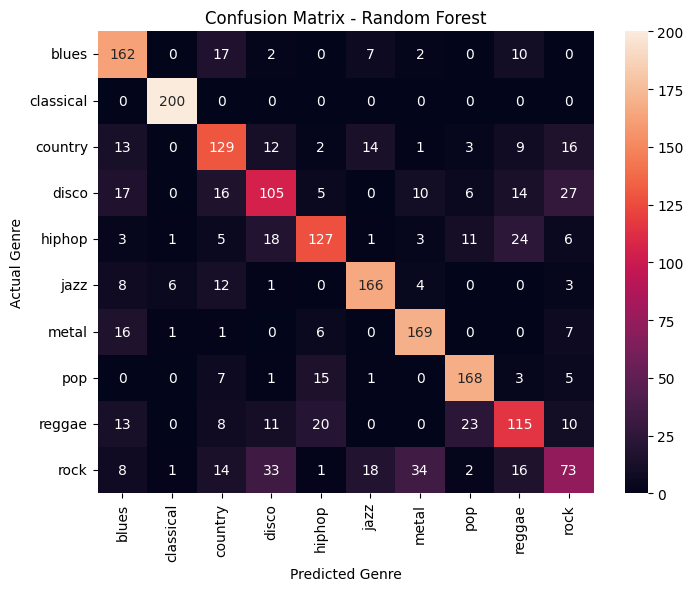

In [72]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [73]:
# Compare the performance of all supervised learning models

model_results = {
    "Logistic Regression": logistic_accuracy * 100,
    "KNN": knn_accuracy * 100,
    "Decision Tree": dt_accuracy * 100,
    "SVM": svm_accuracy * 100,
    "Random Forest": rf_accuracy * 100,
    "Perceptron": perceptron_accuracy * 100
}

print("Model Performance Comparison:\n")

for model, accuracy in model_results.items():
    print(f"{model}: {accuracy:.2f}%")

Model Performance Comparison:

Logistic Regression: 68.07%
KNN: 65.72%
Decision Tree: 50.85%
SVM: 67.37%
Random Forest: 70.77%
Perceptron: 53.40%


## Conclusion

The music genre classification problem was solved using supervised machine learning techniques.

Six classification models were evaluated on the same test dataset: Logistic Regression, KNN, Decision Tree, SVM, Random Forest, and Perceptron.

Among all the models, Random Forest achieved the highest accuracy of 70.77%. Therefore, Random Forest was selected as the best-performing model for predicting the genre of a song.

The confusion matrix shows that the model performs particularly well for genres such as classical, jazz, metal, and pop, while genres such as rock and disco are more difficult to distinguish.

The final model was also used to predict the genre of a test song, demonstrating that the trained model can classify unseen song data.

In [74]:
# Check predictions for the entire test set

all_predictions = random_forest_model.predict(X_test_scaled)

print("Prediction distribution:")
print(pd.Series(all_predictions).value_counts())

print("\nActual distribution:")
print(y_test.value_counts())

Prediction distribution:
blues        240
metal        223
pop          213
country      209
classical    209
jazz         207
reggae       191
disco        183
hiphop       176
rock         147
Name: count, dtype: int64

Actual distribution:
label
blues        200
classical    200
disco        200
jazz         200
pop          200
metal        200
reggae       200
rock         200
hiphop       199
country      199
Name: count, dtype: int64


In [75]:
# Show actual and predicted genres for the first 30 test samples

comparison = pd.DataFrame({
    "Actual": y_test.iloc[:30].values,
    "Predicted": all_predictions[:30]
})

print(comparison)

   Actual Predicted
0   blues     blues
1   blues   country
2   blues   country
3   blues   country
4   blues     blues
5   blues   country
6   blues     blues
7   blues   country
8   blues   country
9   blues     blues
10  blues     blues
11  blues   country
12  blues   country
13  blues     blues
14  blues     blues
15  blues   country
16  blues   country
17  blues   country
18  blues     blues
19  blues     blues
20  blues     blues
21  blues     blues
22  blues   country
23  blues     blues
24  blues   country
25  blues     blues
26  blues     blues
27  blues     blues
28  blues     blues
29  blues     blues
